## Prepare Dataset

### Load the Data

In [1]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d debeshjha1/polypdb

Dataset URL: https://www.kaggle.com/datasets/debeshjha1/polypdb
License(s): unknown
 98% 1.26G/1.29G [00:08<00:00, 187MB/s]
100% 1.29G/1.29G [00:08<00:00, 167MB/s]


In [2]:
!unzip polypdb.zip

Streaming output truncated to the last 5000 lines.
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_06 200731_200730_BN082_005.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_06 200731_200730_BN082_007.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_06 200731_200730_BN083_002.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_06 200731_200730_BN083_003.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_06 200731_200730_BN083_004.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_06 200731_200730_BN083_005.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_07 200808_200725_BN001_002.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_07 200808_200725_BN001_003.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wise/WLI/images/HMUH_07 200808_200728_BN002_002.jpg  
  inflating: PolypDB/PolypDB/PolypDB_modality_wis

### Create Dataset & Split

In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split
import random

def collect_images():
    """Collect all images and their corresponding labels."""
    images = []
    labels = []

    for modality in modalities:
        image_dir = os.path.join(base_data_dir, modality, "images")
        if os.path.exists(image_dir):
            for img_name in os.listdir(image_dir):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    images.append(os.path.join(image_dir, img_name))
                    labels.append(modality)
        else:
            print(f'image path {image_dir} doesn\'t exist')

    return images, labels

def create_dataset_structure():
    """Create train, val, and test directories with class subfolders."""
    train_dir = os.path.join(output_dir, "train")
    val_dir = os.path.join(output_dir, "val")
    test_dir = os.path.join(output_dir, "test")

    # Create directories if they don't exist
    for dir_path in [train_dir, val_dir, test_dir]:
        for modality in modalities:
            class_dir = os.path.join(dir_path, modality_to_class[modality])
            os.makedirs(class_dir, exist_ok=True)

    return train_dir, val_dir, test_dir

def split_and_copy_images(images, labels):
    """Split dataset into train, val, test and copy images to respective folders."""
    # Split dataset: 70% train, 15% val, 15% test
    train_images, temp_images, train_labels, temp_labels = train_test_split(
        images, labels, test_size=0.3, stratify=labels, random_state=42
    )
    val_images, test_images, val_labels, test_labels = train_test_split(
        temp_images, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
    )

    # Copy images to respective directories
    for split_images, split_labels, split_name in [
        (train_images, train_labels, "train"),
        (val_images, val_labels, "val"),
        (test_images, test_labels, "test")
    ]:
        for img_path, label in zip(split_images, split_labels):
            class_dir = os.path.join(output_dir, split_name, modality_to_class[label])
            shutil.copy(img_path, os.path.join(class_dir, os.path.basename(img_path)))


In [4]:
# Define paths
base_data_dir = "PolypDB/PolypDB/PolypDB_modality_wise"
output_dir = "kaggle/working/colonoscopy_dataset"
modalities = ["BLI", "FICE", "LCI", "NBI", "WLI"]

# Mapping modality names to more readable class names
modality_to_class = {
    "BLI": "BlueLightImaging",
    "FICE": "FlexibleSpectralImagingColorEnhancement",
    "LCI": "LinkedColorImaging",
    "NBI": "NarrowBandImaging",
    "WLI": "WhiteLightImaging"
}

# Collect images and labels
images, labels = collect_images()
print(f"Images and labels collected")

Images and labels collected


In [5]:
# Create directory structure
train_dir, val_dir, test_dir = create_dataset_structure()
print(f"Directories created")

Directories created


In [6]:
# Split and copy images
split_and_copy_images(images, labels)

print(f"Dataset prepared successfully at {output_dir}")
print(f"Train set: {train_dir}")
print(f"Validation set: {val_dir}")
print(f"Test set: {test_dir}")

Dataset prepared successfully at kaggle/working/colonoscopy_dataset
Train set: kaggle/working/colonoscopy_dataset/train
Validation set: kaggle/working/colonoscopy_dataset/val
Test set: kaggle/working/colonoscopy_dataset/test


### Data Exploration

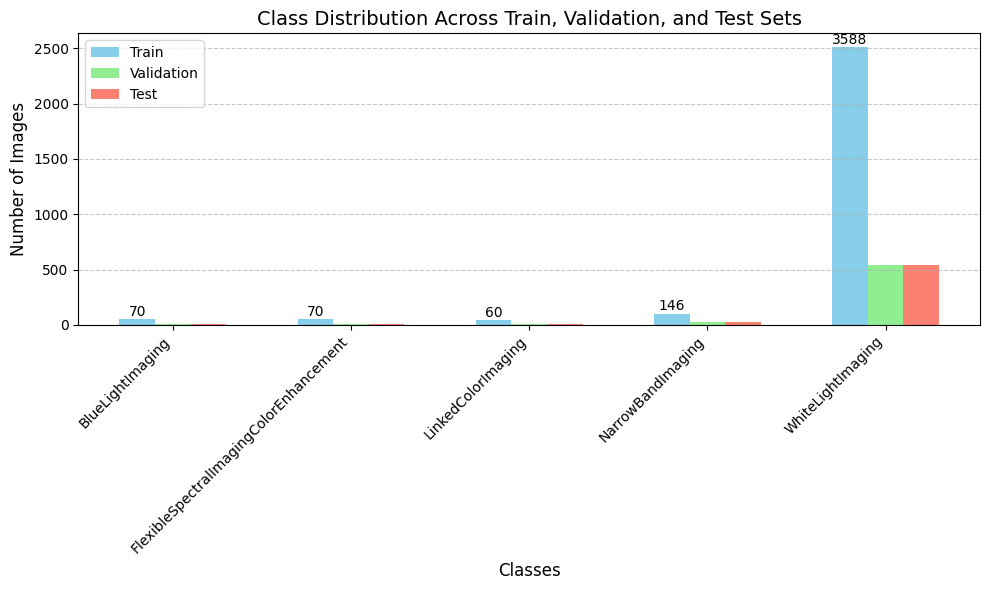


Class Distribution Statistics:
BlueLightImaging: Train=49, Val=10, Test=11, Total=70
FlexibleSpectralImagingColorEnhancement: Train=49, Val=11, Test=10, Total=70
LinkedColorImaging: Train=42, Val=9, Test=9, Total=60
NarrowBandImaging: Train=102, Val=22, Test=22, Total=146
WhiteLightImaging: Train=2511, Val=538, Test=539, Total=3588

Imbalance Ratios (per class total / total images):
BlueLightImaging: 0.018
FlexibleSpectralImagingColorEnhancement: 0.018
LinkedColorImaging: 0.015
NarrowBandImaging: 0.037
WhiteLightImaging: 0.912


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

def analyze_class_distribution(output_dir, modalities, modality_to_class):
    """Analyze and visualize the distribution of classes in the dataset."""
    # Initialize dictionaries to store counts
    class_counts = {modality_to_class[mod]: {'train': 0, 'val': 0, 'test': 0} for mod in modalities}

    # Define split directories
    splits = ['train', 'val', 'test']
    for split in splits:
        split_dir = os.path.join(output_dir, split)
        for modality in modalities:
            class_dir = os.path.join(split_dir, modality_to_class[modality])
            if os.path.exists(class_dir):
                class_counts[modality_to_class[modality]][split] = len(os.listdir(class_dir))
            else:
                print(f"Warning: Directory {class_dir} does not exist.")

    # Prepare data for plotting
    classes = list(class_counts.keys())
    train_counts = [class_counts[cls]['train'] for cls in classes]
    val_counts = [class_counts[cls]['val'] for cls in classes]
    test_counts = [class_counts[cls]['test'] for cls in classes]
    total_counts = [train_counts[i] + val_counts[i] + test_counts[i] for i in range(len(classes))]

    # Create bar plot
    bar_width = 0.2
    index = np.arange(len(classes))

    fig, ax = plt.subplots(figsize=(10, 6))
    plt.bar(index, train_counts, bar_width, label='Train', color='skyblue')
    plt.bar(index + bar_width, val_counts, bar_width, label='Validation', color='lightgreen')
    plt.bar(index + 2 * bar_width, test_counts, bar_width, label='Test', color='salmon')

    # Add total counts as text on top of each group
    for i, total in enumerate(total_counts):
        ax.text(i, max(train_counts[i], val_counts[i], test_counts[i]) + 5, str(total),
                ha='center', va='bottom')

    # Customize plot
    plt.xlabel('Classes', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.title('Class Distribution Across Train, Validation, and Test Sets', fontsize=14)
    plt.xticks(index + bar_width, classes, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Display plot
    plt.show()

    # Print detailed statistics (corrected index access)
    print("\nClass Distribution Statistics:")
    for cls in classes:
        cls_index = list(class_counts.keys()).index(cls)  # Convert keys to list for indexing
        print(f"{cls}: Train={class_counts[cls]['train']}, Val={class_counts[cls]['val']}, "
              f"Test={class_counts[cls]['test']}, Total={total_counts[cls_index]}")

    # Compute imbalance ratio (max/total for each class)
    total_images = sum(total_counts)
    imbalance_ratios = [count / total_images for count in total_counts]
    print("\nImbalance Ratios (per class total / total images):")
    for cls, ratio in zip(classes, imbalance_ratios):
        print(f"{cls}: {ratio:.3f}")


# Analyze and visualize class distribution
analyze_class_distribution(output_dir, modalities, modality_to_class)

### Augment & Create Dataloaders

In [8]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np

# Define paths (consistent with your previous code)
output_dir = "kaggle/working/colonoscopy_dataset"
train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
test_dir = os.path.join(output_dir, "test")

def create_dataloaders(train_dir, val_dir, test_dir, batch_size=32):
    """Create and return DataLoaders for train, validation, and test sets with CutMix and MixUp augmentation."""
    # Basic transformations for all datasets (resize, normalize)
    basic_transforms = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize to match ViT/CNN input
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet norms
    ])

    # Load datasets with basic transforms
    train_dataset = datasets.ImageFolder(train_dir, transform=basic_transforms)
    val_dataset = datasets.ImageFolder(val_dir, transform=basic_transforms)
    test_dataset = datasets.ImageFolder(test_dir, transform=basic_transforms)

    # Custom collate function for CutMix and MixUp
    def collate_fn(batch):
        images, labels = zip(*batch)
        images = torch.stack(images, dim=0)
        labels = torch.tensor(labels, dtype=torch.int64)

        # Apply CutMix with 50% probability
        if torch.rand(1) < 0.5:
            images, labels = v2.CutMix(num_classes=len(train_dataset.classes))(images, labels)

        # Apply MixUp with 50% probability
        if torch.rand(1) < 0.5:
            images, labels = v2.MixUp(num_classes=len(train_dataset.classes))(images, labels)

        return images, labels

    # Create DataLoaders with custom collate function for training
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2,
                             pin_memory=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2,
                           pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2,
                           pin_memory=True)

    print(f"Train loader size: {len(train_loader.dataset)} images")
    print(f"Validation loader size: {len(val_loader.dataset)} images")
    print(f"Test loader size: {len(test_loader.dataset)} images")

    return train_loader, val_loader, test_loader

# Create DataLoaders
train_loader, val_loader, test_loader = create_dataloaders(train_dir, val_dir, test_dir)

Train loader size: 2753 images
Validation loader size: 590 images
Test loader size: 591 images


Visualizing augmented samples from train_loader... 



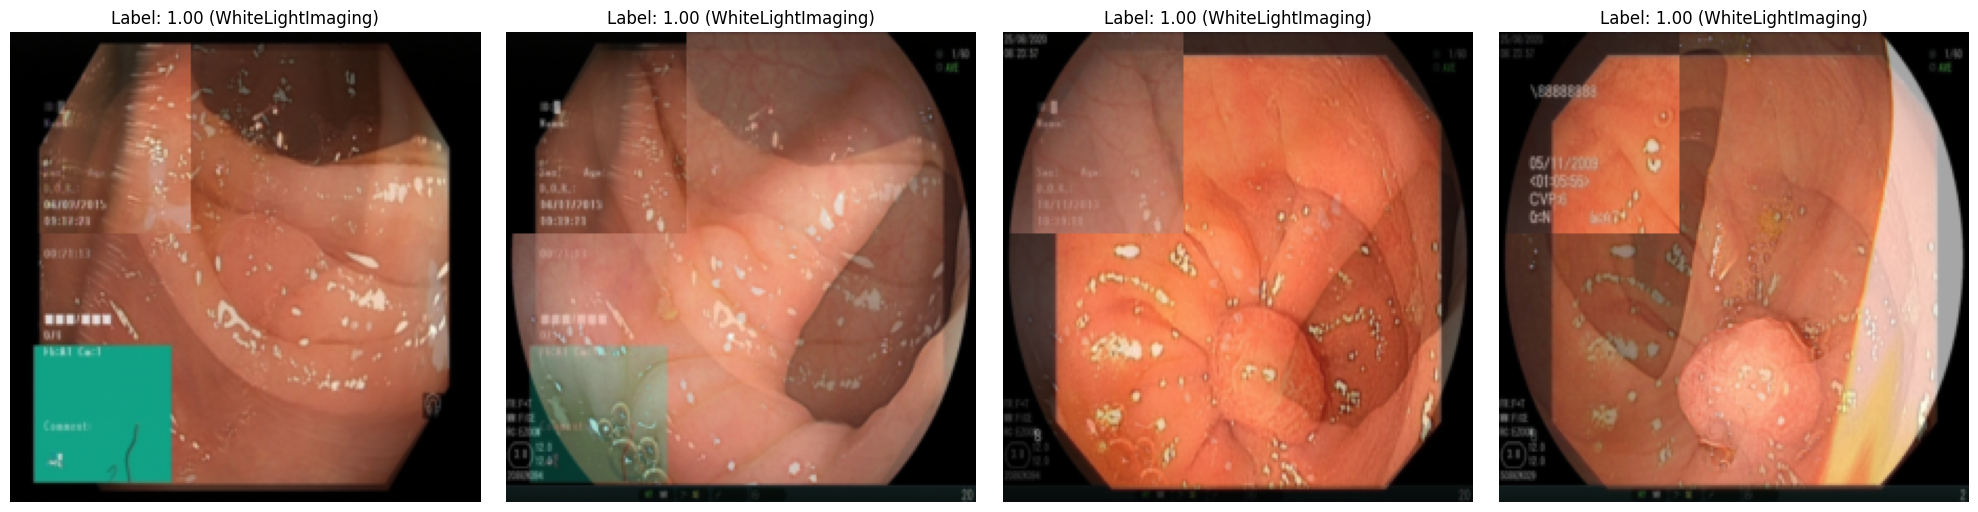

In [9]:
def visualize_augmentations(loader, num_samples=4):
    """Visualize augmented samples from the given DataLoader."""
    # Get a batch
    for images, labels in loader:
        break  # Use the first batch

    # Ensure we have enough samples
    num_samples = min(num_samples, len(images))
    images = images[:num_samples]
    labels = labels[:num_samples]

    # Denormalize using PyTorch (correct broadcasting)
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device)
    std = torch.tensor([0.229, 0.224, 0.225], device=images.device)
    images = images * std.view(1, 3, 1, 1) + mean.view(1, 3, 1, 1)  # Broadcast across batch and spatial dims
    images = torch.clamp(images, 0, 1)  # Clip to [0, 1]

    # Convert to NumPy for visualization
    images = images.permute(0, 2, 3, 1).cpu().numpy()  # CHW to HWC

    # Create figure
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 5, 5))
    class_names = loader.dataset.classes  # Get class names from the dataset

    for i in range(num_samples):
        ax = axes[i] if num_samples > 1 else axes
        ax.imshow(images[i])
        ax.axis('off')
        # For CutMix/MixUp, labels are weighted combinations; use argmax for dominant class index
        if labels[i].dim() > 1:  # Check if labels are one-hot or probability distribution
            dominant_idx = labels[i].argmax().item()  # Get the index of the max value
            label_weight = labels[i].max().item()  # Max weight for display
        else:
            dominant_idx = labels[i].argmax().item()  # Use original label if not mixed
            label_weight = labels[i].max().item() # Full weight for non-mixed
        dominant_class = class_names[dominant_idx]  # Use the index to get class name
        ax.set_title(f"Label: {label_weight:.2f} ({dominant_class})")

    plt.tight_layout()
    plt.show()

# Visualize augmented samples
print("Visualizing augmented samples from train_loader... \n")
visualize_augmentations(train_loader)

## Model

In [10]:
!pip install torchinfo

### Vit-B-16

In [ ]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torchinfo import summary

# Define the hybrid model with fallback ViT
class HybridAttentionModel(nn.Module):
    def __init__(self, num_classes=5):
        super(HybridAttentionModel, self).__init__()

        # 1. Lightweight ViT (fallback for global feature extraction)
        self.vit = torchvision.models.vit_b_16(weights = 'ViT_B_16_Weights.DEFAULT')
        self.vit.heads = nn.Identity()  # Remove classification head
        for param in self.vit.parameters():
            param.requires_grad = False  # Freeze ViT parameters
        # Reduce ViT complexity (optional, adjust layers or hidden size if needed)
        self.vit_feature_dim = 768  # Default output dimension for vit_b_16

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Lightweight Attention Mechanism
        self.attention = nn.MultiheadAttention(embed_dim=self.vit_feature_dim + self.cnn_feature_dim,
                                              num_heads=4, batch_first=True)

        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.vit_feature_dim + self.cnn_feature_dim, 256),  # 768 + 1280 = 2048
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
            # nn.Sigmoid()  # Note: Should be removed for CrossEntropyLoss
        )

    def forward(self, x):
        # Global feature extraction with ViT
        vit_features = self.vit(x)  # Shape: (batch_size, 768)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((vit_features, cnn_features), dim=1)  # Shape: (batch_size, 2048)

        # Apply attention mechanism
        attn_output, _ = self.attention(combined_features.unsqueeze(1), combined_features.unsqueeze(1), combined_features.unsqueeze(1))
        attn_output = attn_output.squeeze(1)  # Shape: (batch_size, 2048)

        # Classification with MLP
        output = self.mlp(attn_output)  # Shape: (batch_size, num_classes)
        return output


# Move model to device for summary (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridAttentionModel(num_classes=5)

# Print model summary using torchinfo
summary(model, input_size=(1, 3, 224, 224), device=device.type)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 124MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s]


Layer (type:depth-idx)                                       Output Shape              Param #
HybridAttentionModel                                         [1, 5]                    --
├─VisionTransformer: 1-1                                     [1, 768]                  768
│    └─Conv2d: 2-1                                           [1, 768, 14, 14]          (590,592)
│    └─Encoder: 2-2                                          [1, 197, 768]             151,296
│    │    └─Dropout: 3-1                                     [1, 197, 768]             --
│    │    └─Sequential: 3-2                                  [1, 197, 768]             (85,054,464)
│    │    └─LayerNorm: 3-3                                   [1, 197, 768]             (1,536)
│    └─Identity: 2-3                                         [1, 768]                  --
├─EfficientNet: 1-2                                          [1, 1280]                 --
│    └─Sequential: 2-4                                       [1, 12

### MobileNetv2

In [ ]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torchinfo import summary

# Define the hybrid model with MobileNetV2
class MobileNetV2AttentionModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV2AttentionModel, self).__init__()

        # 1. Lightweight MobileNetV2 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v2(weights = 'MobileNet_V2_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 1280  # Output dimension for MobileNetV2 before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Lightweight Attention Mechanism
        self.attention = nn.MultiheadAttention(embed_dim=self.mobilenet_feature_dim + self.cnn_feature_dim,
                                              num_heads=4, batch_first=True)

        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 1280 + 1280 = 2560
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
            # nn.Sigmoid()  # Note: Should be removed for CrossEntropyLoss
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV2
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 1280)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 2560)

        # Apply attention mechanism
        attn_output, _ = self.attention(combined_features.unsqueeze(1), combined_features.unsqueeze(1), combined_features.unsqueeze(1))
        attn_output = attn_output.squeeze(1)  # Shape: (batch_size, 2560)

        # Classification with MLP
        output = self.mlp(attn_output)  # Shape: (batch_size, num_classes)
        return output


# Move model to device for summary (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetV2AttentionModel(num_classes=5)

# Print model summary using torchinfo
summary(model, input_size=(1, 3, 224, 224), device=device.type)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 118MB/s]


Layer (type:depth-idx)                                       Output Shape              Param #
MobileNetV2AttentionModel                                    [1, 5]                    --
├─MobileNetV2: 1-1                                           [1, 1280]                 --
│    └─Sequential: 2-1                                       [1, 1280, 7, 7]           --
│    │    └─Conv2dNormActivation: 3-1                        [1, 32, 112, 112]         (928)
│    │    └─InvertedResidual: 3-2                            [1, 16, 112, 112]         (896)
│    │    └─InvertedResidual: 3-3                            [1, 24, 56, 56]           (5,136)
│    │    └─InvertedResidual: 3-4                            [1, 24, 56, 56]           (8,832)
│    │    └─InvertedResidual: 3-5                            [1, 32, 28, 28]           (10,000)
│    │    └─InvertedResidual: 3-6                            [1, 32, 28, 28]           (14,848)
│    │    └─InvertedResidual: 3-7                            [1, 32

### MobileNetv2Conv

In [ ]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torchinfo import summary

# Define the hybrid model with MobileNetV2 and a convolutional layer
class MobileNetV2ConvModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV2ConvModel, self).__init__()

        # 1. Lightweight MobileNetV2 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v2(weights = 'MobileNet_V2_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 1280  # Output dimension for MobileNetV2 before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Convolutional layer
        self.conv = nn.Conv1d(in_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              out_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              kernel_size=1)


        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 1280 + 1280 = 2560
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV2
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 1280)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 2560)

        # Apply convolutional layer
        conv_output = self.conv(combined_features.unsqueeze(2)).squeeze(2) # Shape: (batch_size, 2560)


        # Classification with MLP
        output = self.mlp(conv_output)  # Shape: (batch_size, num_classes)
        return output


# Move model to device for summary (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetV2ConvModel(num_classes=5)

# Print model summary using torchinfo
summary(model, input_size=(1, 3, 224, 224), device=device.type)

Layer (type:depth-idx)                                       Output Shape              Param #
MobileNetV2ConvModel                                         [1, 5]                    --
├─MobileNetV2: 1-1                                           [1, 1280]                 --
│    └─Sequential: 2-1                                       [1, 1280, 7, 7]           --
│    │    └─Conv2dNormActivation: 3-1                        [1, 32, 112, 112]         (928)
│    │    └─InvertedResidual: 3-2                            [1, 16, 112, 112]         (896)
│    │    └─InvertedResidual: 3-3                            [1, 24, 56, 56]           (5,136)
│    │    └─InvertedResidual: 3-4                            [1, 24, 56, 56]           (8,832)
│    │    └─InvertedResidual: 3-5                            [1, 32, 28, 28]           (10,000)
│    │    └─InvertedResidual: 3-6                            [1, 32, 28, 28]           (14,848)
│    │    └─InvertedResidual: 3-7                            [1, 32

### MobileNetv3Conv

In [ ]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torchinfo import summary

# Define the hybrid model with MobileNetV3-small and a convolutional layer
class MobileNetV3ConvModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV3ConvModel, self).__init__()

        # 1. Lightweight MobileNetV3 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v3_small(weights = 'MobileNet_V3_Small_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 576  # Output dimension for MobileNetV3-small before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Convolutional layer
        self.conv = nn.Conv1d(in_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              out_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              kernel_size=1)


        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 576 + 1280 = 1856
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV3
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 576)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 1856)

        # Apply convolutional layer
        conv_output = self.conv(combined_features.unsqueeze(2)).squeeze(2) # Shape: (batch_size, 1856)


        # Classification with MLP
        output = self.mlp(conv_output)  # Shape: (batch_size, num_classes)
        return output


# Move model to device for summary (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetV3ConvModel(num_classes=5)

# Print model summary using torchinfo
summary(model, input_size=(1, 3, 224, 224), device=device.type)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 130MB/s]


Layer (type:depth-idx)                                       Output Shape              Param #
MobileNetV3ConvModel                                         [1, 5]                    --
├─MobileNetV3: 1-1                                           [1, 576]                  --
│    └─Sequential: 2-1                                       [1, 576, 7, 7]            --
│    │    └─Conv2dNormActivation: 3-1                        [1, 16, 112, 112]         (464)
│    │    └─InvertedResidual: 3-2                            [1, 16, 56, 56]           (744)
│    │    └─InvertedResidual: 3-3                            [1, 24, 28, 28]           (3,864)
│    │    └─InvertedResidual: 3-4                            [1, 24, 28, 28]           (5,416)
│    │    └─InvertedResidual: 3-5                            [1, 40, 14, 14]           (13,736)
│    │    └─InvertedResidual: 3-6                            [1, 40, 14, 14]           (57,264)
│    │    └─InvertedResidual: 3-7                            [1, 40

### EfficientNet-Only

In [18]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torchinfo import summary

# Define the lightweight EfficientNet-only model
class LightweightEfficientNetModel(nn.Module):
    def __init__(self, num_classes=5):
        super(LightweightEfficientNetModel, self).__init__()

        # Use EfficientNet-B0 as the backbone (lightweight version)
        self.backbone = torchvision.models.efficientnet_b0(weights='EfficientNet_B0_Weights.DEFAULT')
        self.backbone.classifier = nn.Identity()  # Remove original classifier
        # Freeze most of the backbone parameters to make it lighter
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Only unfreeze the last few layers for fine-tuning
        for param in self.backbone.features[-3:].parameters():
            param.requires_grad = True

        self.backbone_feature_dim = 1280  # EfficientNet-B0 output features

        # Lightweight classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(self.backbone_feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Extract features using EfficientNet backbone
        features = self.backbone.features(x)

        # Apply our custom classifier
        output = self.classifier(features)

        return output


# Move model to device for summary (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LightweightEfficientNetModel(num_classes=5)

# Print model summary using torchinfo
summary(model, input_size=(1, 3, 224, 224), device=device.type)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 100MB/s]


Layer (type:depth-idx)                                       Output Shape              Param #
LightweightEfficientNetModel                                 [1, 5]                    --
├─EfficientNet: 1-1                                          --                        --
│    └─Sequential: 2-1                                       [1, 1280, 7, 7]           --
│    │    └─Conv2dNormActivation: 3-1                        [1, 32, 112, 112]         (928)
│    │    └─Sequential: 3-2                                  [1, 16, 112, 112]         (1,448)
│    │    └─Sequential: 3-3                                  [1, 24, 56, 56]           (16,714)
│    │    └─Sequential: 3-4                                  [1, 40, 28, 28]           (46,640)
│    │    └─Sequential: 3-5                                  [1, 80, 14, 14]           (242,930)
│    │    └─Sequential: 3-6                                  [1, 112, 14, 14]          (543,148)
│    │    └─Sequential: 3-7                                  

### MobileNetv2-Only

In [11]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torchinfo import summary

# Define the MobileNetV2-only model
class MobileNetV2OnlyModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV2OnlyModel, self).__init__()

        # 1. Lightweight MobileNetV2 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v2(weights = 'MobileNet_V2_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters

        # Only unfreeze the last few layers for fine-tuning
        # Adjust the number of layers to unfreeze based on experimentation
        for param in self.mobilenet.features[-3:].parameters():
             param.requires_grad = True

        self.mobilenet_feature_dim = 1280  # Output dimension for MobileNetV2 before classifier

        # 2. MLP for classification
        self.mlp = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(self.mobilenet_feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV2
        mobilenet_features = self.mobilenet.features(x)  # Shape: (batch_size, 1280)

        # Classification with MLP
        output = self.mlp(mobilenet_features)  # Shape: (batch_size, num_classes)
        return output


# Move model to device for summary (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MobileNetV2OnlyModel(num_classes=5)

# Print model summary using torchinfo
summary(model, input_size=(1, 3, 224, 224), device=device.type)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 64.7MB/s]


Layer (type:depth-idx)                                  Output Shape              Param #
MobileNetV2OnlyModel                                    [1, 5]                    --
├─MobileNetV2: 1-1                                      --                        --
│    └─Sequential: 2-1                                  [1, 1280, 7, 7]           --
│    │    └─Conv2dNormActivation: 3-1                   [1, 32, 112, 112]         (928)
│    │    └─InvertedResidual: 3-2                       [1, 16, 112, 112]         (896)
│    │    └─InvertedResidual: 3-3                       [1, 24, 56, 56]           (5,136)
│    │    └─InvertedResidual: 3-4                       [1, 24, 56, 56]           (8,832)
│    │    └─InvertedResidual: 3-5                       [1, 32, 28, 28]           (10,000)
│    │    └─InvertedResidual: 3-6                       [1, 32, 28, 28]           (14,848)
│    │    └─InvertedResidual: 3-7                       [1, 32, 28, 28]           (14,848)
│    │    └─InvertedResidu

## Train

In [19]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm

# Training function with history tracking and plotting
def train_model(model, train_loader, val_loader, num_epochs=10, save_path="kaggle/working/best_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)  # All trainable parameters

    best_val_loss = float('inf')
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in tqdm(range(num_epochs), desc="Training Epochs", unit="epoch", dynamic_ncols=True, leave=True):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels.argmax(dim=1) if labels.dim() > 1 else labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == (labels.argmax(dim=1) if labels.dim() > 1 else labels)).sum().item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == (labels.argmax(dim=1) if labels.dim() > 1 else labels)).sum().item()

        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # Save best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model with val loss: {best_val_loss:.4f}")

    return model, history

# Testing function with confusion matrix
def test_model(model, test_loader, load_path="kaggle/working/best_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Load the best model
    model.load_state_dict(torch.load(load_path))
    model.eval()

    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels.argmax(dim=1) if labels.dim() > 1 else labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            true_labels = labels.argmax(dim=1) if labels.dim() > 1 else labels
            total += labels.size(0)
            correct += (predicted == true_labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(true_labels.cpu().numpy())

    test_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%")

    # Generate and visualize confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(5), yticklabels=range(5))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return accuracy


In [20]:
[model, history] = train_model(model, train_loader, val_loader)

Training Epochs:  10%|█         | 1/10 [00:33<04:58, 33.19s/epoch]

Epoch 1/10, Train Loss: 0.3565, Train Acc: 90.77%, Val Loss: 0.1940, Val Acc: 93.22%
Saved best model with val loss: 0.1940


Training Epochs:  20%|██        | 2/10 [01:07<04:28, 33.57s/epoch]

Epoch 2/10, Train Loss: 0.1993, Train Acc: 93.17%, Val Loss: 0.1629, Val Acc: 95.08%
Saved best model with val loss: 0.1629


Training Epochs:  30%|███       | 3/10 [01:42<03:59, 34.27s/epoch]

...

Epoch 8/10, Train Loss: 0.0796, Train Acc: 97.75%, Val Loss: 0.0777, Val Acc: 97.97%


Training Epochs:  90%|█████████ | 9/10 [05:07<00:33, 33.99s/epoch]

Epoch 9/10, Train Loss: 0.0893, Train Acc: 97.13%, Val Loss: 0.0346, Val Acc: 99.32%
Saved best model with val loss: 0.0346


Training Epochs: 100%|██████████| 10/10 [05:44<00:00, 34.44s/epoch]

Epoch 10/10, Train Loss: 0.0763, Train Acc: 97.31%, Val Loss: 0.0314, Val Acc: 99.15%
Saved best model with val loss: 0.0314


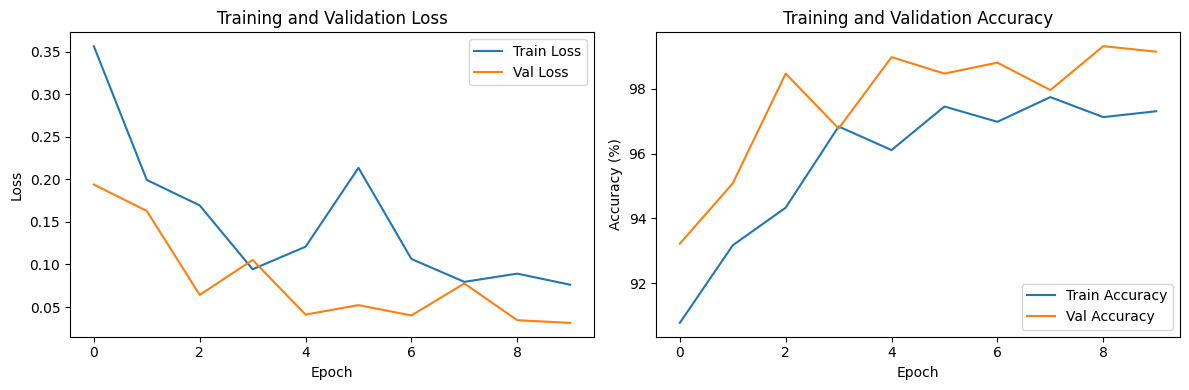

In [21]:
def visualize_train_history(history):
    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

visualize_train_history(history)

## Test from Loader

Test Loss: 0.0139, Accuracy: 99.66%


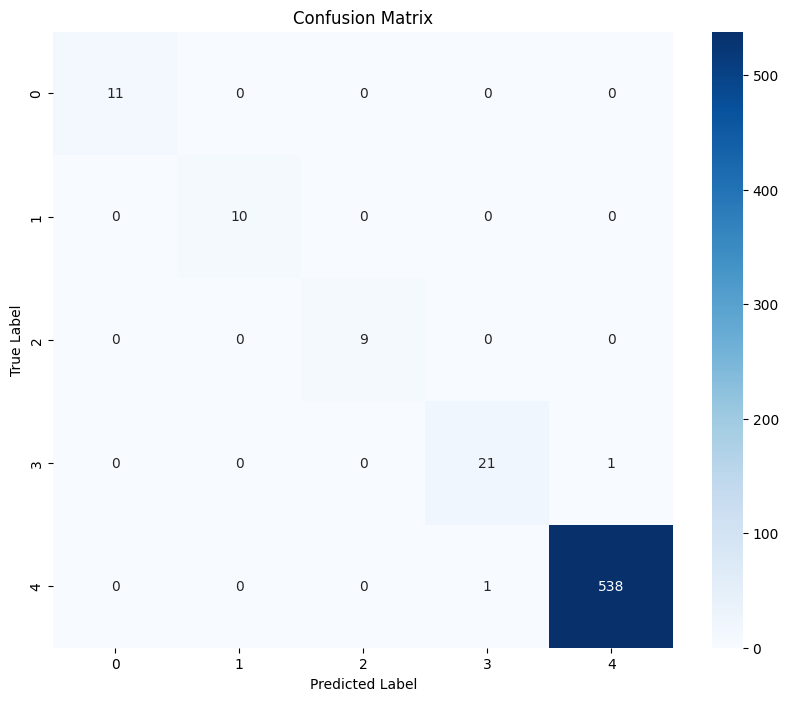

99.66159052453469

In [22]:
test_model(model, test_loader)

In [23]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Define source and destination paths
source_path = "kaggle/working/best_model.pth"
destination_path = "/content/drive/MyDrive/iMIAP-Project/best_efficientnet_model_2.pth"

# Ensure the source file exists
if os.path.exists(source_path):
    # Copy the file
    shutil.copy(source_path, destination_path)
    print(f"Model checkpoint copied to: {destination_path}")
else:
    print(f"Source file not found: {source_path}")

Mounted at /content/drive
Model checkpoint copied to: /content/drive/MyDrive/iMIAP-Project/best_efficientnet_model_2.pth


## Test from files

In [ ]:
import os
import numpy
import pandas as pd

import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn as nn

# Define the hybrid model with fallback ViT
class HybridAttentionModel(nn.Module):
    def __init__(self, num_classes=5):
        super(HybridAttentionModel, self).__init__()

        # 1. Lightweight ViT (fallback for global feature extraction)
        self.vit = torchvision.models.vit_b_16(weights = 'ViT_B_16_Weights.DEFAULT')
        self.vit.heads = nn.Identity()  # Remove classification head
        for param in self.vit.parameters():
            param.requires_grad = False  # Freeze ViT parameters
        # Reduce ViT complexity (optional, adjust layers or hidden size if needed)
        self.vit_feature_dim = 768  # Default output dimension for vit_b_16

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Lightweight Attention Mechanism
        self.attention = nn.MultiheadAttention(embed_dim=self.vit_feature_dim + self.cnn_feature_dim,
                                              num_heads=4, batch_first=True)

        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.vit_feature_dim + self.cnn_feature_dim, 256),  # 768 + 1280 = 2048
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
            # nn.Sigmoid()  # Note: Should be removed for CrossEntropyLoss
        )

    def forward(self, x):
        # Global feature extraction with ViT
        vit_features = self.vit(x)  # Shape: (batch_size, 768)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((vit_features, cnn_features), dim=1)  # Shape: (batch_size, 2048)

        # Apply attention mechanism
        attn_output, _ = self.attention(combined_features.unsqueeze(1), combined_features.unsqueeze(1), combined_features.unsqueeze(1))
        attn_output = attn_output.squeeze(1)  # Shape: (batch_size, 2048)

        # Classification with MLP
        output = self.mlp(attn_output)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Define the hybrid model with MobileNetV2
class MobileNetV2AttentionModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV2AttentionModel, self).__init__()

        # 1. Lightweight MobileNetV2 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v2(weights = 'MobileNet_V2_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 1280  # Output dimension for MobileNetV2 before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Lightweight Attention Mechanism
        self.attention = nn.MultiheadAttention(embed_dim=self.mobilenet_feature_dim + self.cnn_feature_dim,
                                              num_heads=4, batch_first=True)

        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 1280 + 1280 = 2560
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
            # nn.Sigmoid()  # Note: Should be removed for CrossEntropyLoss
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV2
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 1280)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 2560)

        # Apply attention mechanism
        attn_output, _ = self.attention(combined_features.unsqueeze(1), combined_features.unsqueeze(1), combined_features.unsqueeze(1))
        attn_output = attn_output.squeeze(1)  # Shape: (batch_size, 2560)

        # Classification with MLP
        output = self.mlp(attn_output)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Define the hybrid model with MobileNetV2 and a convolutional layer
class MobileNetV2ConvModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV2ConvModel, self).__init__()

        # 1. Lightweight MobileNetV2 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v2(weights = 'MobileNet_V2_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 1280  # Output dimension for MobileNetV2 before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Convolutional layer
        self.conv = nn.Conv1d(in_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              out_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              kernel_size=1)


        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 1280 + 1280 = 2560
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV2
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 1280)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 2560)

        # Apply convolutional layer
        conv_output = self.conv(combined_features.unsqueeze(2)).squeeze(2) # Shape: (batch_size, 2560)


        # Classification with MLP
        output = self.mlp(conv_output)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Define the hybrid model with MobileNetV3-small and a convolutional layer
class MobileNetV3ConvModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV3ConvModel, self).__init__()

        # 1. Lightweight MobileNetV3 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v3_small(weights = 'MobileNet_V3_Small_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 576  # Output dimension for MobileNetV3-small before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Convolutional layer
        self.conv = nn.Conv1d(in_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              out_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              kernel_size=1)


        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 576 + 1280 = 1856
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV3
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 576)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 1856)

        # Apply convolutional layer
        conv_output = self.conv(combined_features.unsqueeze(2)).squeeze(2) # Shape: (batch_size, 1856)


        # Classification with MLP
        output = self.mlp(conv_output)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
# ----------------------------------------------------------------------------------------------------------------------- #
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Testing function from files and with label saving
def test_model(model, test_data_dir, load_path="best_model.pth", output_file="test_predictions.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Load the best model
    model.load_state_dict(torch.load(load_path))
    model.eval()

    # Create DataLoader from directory
    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    test_dataset = datasets.ImageFolder(test_data_dir, transform=test_transforms)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    all_preds = []
    all_labels = []
    filenames = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Get filenames for the current batch
            batch_filenames = [test_dataset.samples[i * test_loader.batch_size + j][0] for j in range(images.size(0))]
            filenames.extend(batch_filenames)


    test_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%")

    # Save filenames and predicted labels to a CSV file
    results_df = pd.DataFrame({'file_name': filenames, 'class_label': [test_dataset.classes[pred] for pred in all_preds]})
    results_df.to_csv(output_file, index=False)

    print(f"Test predictions saved to {output_file}")


    # Generate and visualize confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return accuracy

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)
# Define the path to the saved model in Google Drive
model_path = "/content/drive/MyDrive/iMIAP-Project/best_colonoscopy_model_vit.pth"

# Check if the model file exists
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found at: {model_path}")

Test Loss: 0.0442, Accuracy: 98.48%
Test predictions saved to test_predictions.txt


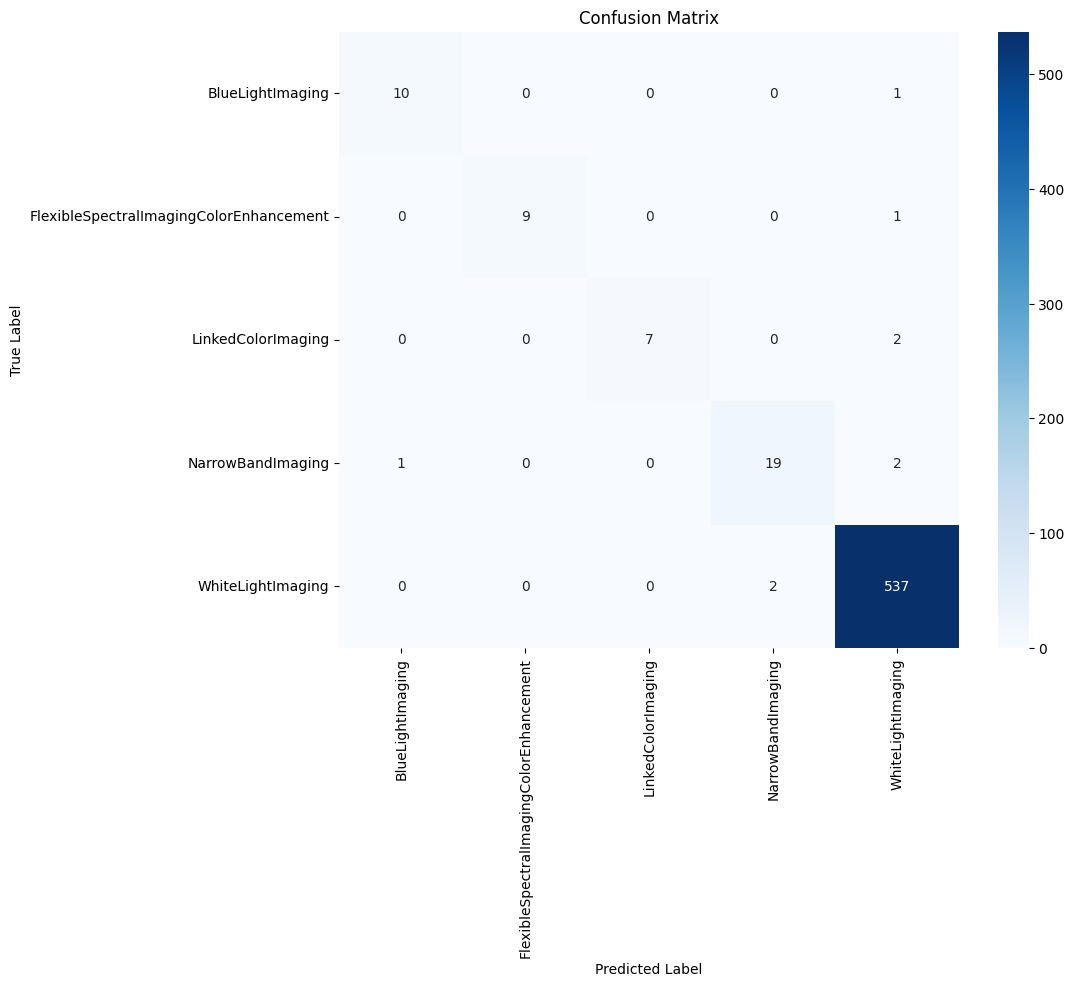

In [ ]:
# Define the test data directory
test_data_dir = os.path.join(output_dir, "test")

# Initialize the desired model
model = HybridAttentionModel(num_classes=5)
model = MobileNetV2AttentionModel(num_classes=5)
model = MobileNetV2ConvModel(num_classes=5)
model = MobileNetV3ConvModel(num_classes=5)

# Test the model using the test data directory
test_accuracy = test_model(model, test_data_dir, model_path)